# Forward Curve Evaluation

This notebook evaluates forward curve recipes (PCHIP and Kalman) using:
- **Put-call parity**: Compare fitted forwards to options-implied forwards
- **Pillar fit quality**: WMAE between fitted curve and pillar observations
- **Leave-one-expiry-out (LOEO)**: Cross-validation by excluding each pillar

## Key Design

All evaluations use `assign_forwards()` from `okx.recipes.forwards` to match forward
prices to data. This keeps the pipeline consistent and leverages the caching system.

## Imports

In [27]:
%load_ext autoreload
%autoreload 2

from datetime import date, datetime, timedelta
from functools import partial
from typing import Dict, Optional

import numpy as np
import polars as pl
from tqdm import tqdm
import matplotlib.pyplot as plt

from okx.store import OrderbookStore
from okx.recipes.forwards import build_forwards_pchip, build_forwards_kalman, assign_forwards
from okx.recipes.options import prepare_options
from evaluation.forwards_eval import evaluate_parity, summarize_parity, evaluate_pillar_fit, evaluate_loeo, summarize_pillar_fit

from evaluation.plotting import plot_error_histogram, plot_error_over_time, plot_error_by_group

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Store Configuration

In [11]:
store = OrderbookStore(
    data_root="data/okx",
    manifest_path="data/okx/manifest.sqlite"
)

In [16]:
store.clear_cache()

Cleared all caches


## Evaluation Parameters

In [ ]:
# Shared parameters
inst_family = 'BTC-USD'

# Scenario (a): Full month with binning
def make_dates(start_date: date, num_days: int) -> list[date]:
    return [start_date + timedelta(days=i) for i in range(num_days)]

dates_month = make_dates(date(2025, 9, 1), 30)
binning_month = '5m'

# Put-call parity filters
moneyness_spread = 0.05

# Recipe configurations
recipes = {
    'pchip': build_forwards_pchip,
    'kalman': build_forwards_kalman
}

batch_days = 5

# Scratchpad/Testing

In [17]:
lf_pillar_fit = evaluate_pillar_fit(
    store=store,
    dates=dates_day,
    inst_family=inst_family,
    forwards_recipe=recipes['kalman'],
    binning=binning_day,
    unique_times=unique_times,
    verbose=True,
)

Preparing pillars for 1 dates...
Constructing pillars for BTC-USD with swap and futures using provided timestamps
 - Time taken to fetch swap and futures: 0:00:04.591243
 - Time taken to align snapshots: 0:00:00.087602


/Users/pascalandreas/Documents/repositories/final-year-project/okx/recipes/pillars.py:56: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  


 - Time taken to concatenate and filter: 0:00:01.463475
 - Time taken to index and sort pillars: 0:00:00.000151
 - Total time taken to prepare pillars: 0:00:06.142471
Assigning kalman forwards to 1 dates using kalman forwards


<sys>:0: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided


 - Time taken to collect data: 0:00:05.814469
[store] Getting derived data via recipe 'build_forwards_kalman' for 1 dates
Building Kalman-filtered Nelson-Siegel forwards for BTC-USD with provided timestamps
Constructing pillars for BTC-USD with swap and futures using provided timestamps
 - Time taken to fetch swap and futures: 0:00:04.371510
 - Time taken to align snapshots: 0:00:00.092540
 - Time taken to concatenate and filter: 0:00:01.451711
 - Time taken to index and sort pillars: 0:00:00.000235
 - Total time taken to prepare pillars: 0:00:05.915996
 - Time taken to prepare and collect pillars: 0:00:11.936863
 - Time taken to build 6312282 snapshots: 0:00:46.097786 


Kalman filter:   0%|          | 0/6312282 [00:00<?, ?it/s]

 - Time taken to run Kalman filter: 0:05:02.583037
 - Time taken to convert states to Polars: 0:00:01.456057
 - Total time taken to build Kalman forwards: 0:06:02.073743
 - Time taken to fetch forwards: 0:06:08.938058
 - Time taken to build forward lookup: 0:00:28.979906


Matching forwards: 100%|██████████| 6312282/6312282 [01:52<00:00, 56339.53it/s]


 - Time taken to match forwards: 0:01:52.474086, matched 44,185,935 / 44,185,935 rows
 - Total time taken to assign forwards: 0:08:30.392050


In [18]:
df_summary = summarize_pillar_fit(lf_pillar_fit).collect()
df_summary.head()
print(df_summary)

shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ error_mid_bps_ ┆ error_mid_bps_ ┆ error_bid_bps_ ┆ error_ask_bps ┆ spread_obs_bp ┆ spread_pred_b │
│ mean           ┆ std            ┆ mean           ┆ _mean         ┆ s_mean        ┆ ps_mean       │
│ ---            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│ f64            ┆ f64            ┆ f64            ┆ f64           ┆ f64           ┆ f64           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 2.190634       ┆ 1.625446       ┆ 2.359713       ┆ 2.102776      ┆ 0.672143      ┆ 0.009795      │
└────────────────┴────────────────┴────────────────┴───────────────┴───────────────┴───────────────┘


In [14]:
metrics = lf_errors.group_by(['pillar_idx']).agg([
    pl.col('error_bid_bps').mean().alias('mae_bid_bps'),
    pl.col('error_ask_bps').mean().alias('mae_ask_bps'),
    pl.col('error_mid_bps').mean().alias('mae_mid_bps'),
    ((pl.col('F_ask_obs') < pl.col('F_bid_pred')).sum() / pl.len()).alias('spread_above_pct'),
    ((pl.col('F_bid_obs') > pl.col('F_ask_pred')).sum() / pl.len()).alias('spread_below_pct'),
]).collect()
metrics.sort('pillar_idx').head()


pillar_idx,mae_bid_bps,mae_ask_bps,mae_mid_bps,spread_above_pct,spread_below_pct
i64,f64,f64,f64,f64,f64
1,2.011165,2.113883,2.058759,0.129876,0.851835
2,2.285127,2.209824,2.241302,0.564301,0.408612
3,4.017288,3.907714,3.957395,0.753444,0.231856
4,2.673521,2.45376,2.55275,0.685612,0.277926
5,1.823463,1.819796,1.821302,0.663503,0.329784


In [17]:
lf_loeo = evaluate_loeo(
    store=store,
    dates=dates_month,  # First 3 days only
    inst_family=inst_family,
    forwards_recipe=recipes['kalman'],
    binning=binning_month,
    verbose=True,
)

Running LOEO evaluation for 30 dates...
Constructing pillars for BTC-USD with swap and futures using 5m binning
 - Time taken to fetch swap and futures: 0:00:00.012235
 - Time taken to align snapshots: 0:00:00.000038
 - Time taken to concatenate and filter: 0:00:00.005065
 - Time taken to index and sort pillars: 0:00:00.000072
 - Total time taken to prepare pillars: 0:00:00.017410
Evaluating 7 pillars...


LOEO pillar indices:   0%|          | 0/7 [00:00<?, ?it/s]

Assigning kalman forwards to 30 dates using kalman forwards
 - Time taken to collect data: 0:00:00.000099
[store] Getting derived data via recipe 'build_forwards_kalman' for 30 dates
 - Time taken to fetch forwards: 0:00:00.007432
 - Time taken to build forward lookup: 0:00:00.031602


LOEO pillar indices:  14%|█▍        | 1/7 [00:00<00:00,  6.37it/s]

 - Time taken to match forwards: 0:00:00.117449, matched 8,639 / 8,639 rows
 - Total time taken to assign forwards: 0:00:00.156483
Assigning kalman forwards to 30 dates using kalman forwards
 - Time taken to collect data: 0:00:00.000097
[store] Getting derived data via recipe 'build_forwards_kalman' for 30 dates
 - Time taken to fetch forwards: 0:00:00.007546
 - Time taken to build forward lookup: 0:00:00.030093


...

 - Time taken to match forwards: 0:00:00.120784, matched 8,639 / 8,639 rows
 - Total time taken to assign forwards: 0:00:00.157453
Assigning kalman forwards to 30 dates using kalman forwards
 - Time taken to collect data: 0:00:00.000092
[store] Getting derived data via recipe 'build_forwards_kalman' for 30 dates
 - Time taken to fetch forwards: 0:00:00.007114
 - Time taken to build forward lookup: 0:00:00.029315


LOEO pillar indices:  86%|████████▌ | 6/7 [00:01<00:00,  5.57it/s]

 - Time taken to match forwards: 0:00:00.184349, matched 8,639 / 8,639 rows
 - Total time taken to assign forwards: 0:00:00.220778
Assigning kalman forwards to 30 dates using kalman forwards
 - Time taken to collect data: 0:00:00.000088
[store] Getting derived data via recipe 'build_forwards_kalman' for 30 dates
 - Time taken to fetch forwards: 0:00:00.007527
 - Time taken to build forward lookup: 0:00:00.030362


LOEO pillar indices: 100%|██████████| 7/7 [00:01<00:00,  6.06it/s]

 - Time taken to match forwards: 0:00:00.106314, matched 7,775 / 7,775 rows
 - Total time taken to assign forwards: 0:00:00.144203


In [18]:
df_summary = summarize_pillar_fit(lf_loeo).collect()
df_summary.head()

error_mid_bps_mean,error_mid_bps_std,error_bid_bps_mean,error_ask_bps_mean,spread_obs_bps_mean,spread_pred_bps_mean
f64,f64,f64,f64,f64,f64
5.84753,7.672553,5.900529,5.803467,0.269112,0.008941


In [21]:
metrics = lf_loeo.group_by(['pillar_idx']).agg([
    pl.col('error_bid_bps').mean().alias('mae_bid_bps'),
    pl.col('error_ask_bps').mean().alias('mae_ask_bps'),
    pl.col('error_mid_bps').mean().alias('mae_mid_bps'),
    ((pl.col('F_ask_obs') < pl.col('F_bid_pred')).sum() / pl.len()).alias('spread_above_pct'),
    ((pl.col('F_bid_obs') > pl.col('F_ask_pred')).sum() / pl.len()).alias('spread_below_pct'),
]).collect()
metrics.sort('pillar_idx').head()

pillar_idx,mae_bid_bps,mae_ask_bps,mae_mid_bps,spread_above_pct,spread_below_pct
i64,f64,f64,f64,f64,f64
1,2.014199,2.116944,2.06182,0.12976,0.85195
2,2.341062,2.265646,2.297269,0.564996,0.408265
3,4.459518,4.350499,4.40049,0.754254,0.233013
4,3.52679,3.303434,3.406731,0.69603,0.278504
5,2.897832,2.89414,2.895753,0.665471,0.330247


# Full Evaluation Suite

Evaluate both recipes on 2025-09-01 to 2025-09-30 with 5-minute binning.

In [14]:
results_month = {}

for recipe_name, recipe_fn in recipes.items():
    print(f"\n{'='*60}")
    print(f"Evaluating {recipe_name.upper()} on FULL MONTH with {binning_month} binning")
    print(f"{'='*60}\n")
    
    results_month[recipe_name] = {}
    recipe_fn = partial(recipe_fn, inst_family=inst_family, batch_days=batch_days, verbose=True)
    # Put-call parity
    print(f"\n--- Put-Call Parity ---")
    lf_parity = evaluate_parity(
        store=store,
        dates=dates_month,
        inst_family=inst_family,
        forwards_recipe=recipe_fn,
        binning=binning_month,
        moneyness_spread=moneyness_spread,
        batch_days=batch_days,
        verbose=True,
    )
    results_month[recipe_name]['parity'] = lf_parity
    print("\nSummary:")
    print(summarize_parity(lf_parity).collect())
    
    # Pillar fit
    print(f"\n--- Pillar Fit Quality ---")
    lf_pillar_fit = evaluate_pillar_fit(
        store=store,
        dates=dates_month,
        inst_family=inst_family,
        forwards_recipe=recipe_fn,
        binning=binning_month,
        verbose=True,
    )
    results_month[recipe_name]['pillar_fit'] = lf_pillar_fit
    print("\nSummary:")
    print(summarize_pillar_fit(lf_pillar_fit).collect())
    
    # LOEO - sample first 3 days only for speed
    print(f"\n--- Leave-One-Expiry-Out ---")
    lf_loeo = evaluate_loeo(
        store=store,
        dates=dates_month,  # First 3 days only
        inst_family=inst_family,
        forwards_recipe=recipe_fn,
        binning=binning_month,
        verbose=True,
    )
    results_month[recipe_name]['loeo'] = lf_loeo
    
    print("\nSummary:")
    print(summarize_pillar_fit(lf_loeo).collect())



Evaluating PCHIP on FULL MONTH with 5m binning


--- Put-Call Parity ---
Preparing paired options data for BTC-USD for 30 dates using build_forwards_pchip and 5m binning
[store] Getting BTC-USD/OPTION for 30 dates (depth=1, 5m binning, 7 features)


Processing batches:   0%|          | 0/6 [00:00<?, ?it/s]

 - Time taken to fetch options: 0:00:19.271596
[store] Getting BTC-USD/SPOT for 30 dates (depth=0, 5m binning, 5 features)


Processing batches:   0%|          | 0/6 [00:00<?, ?it/s]

 - Time taken to fetch spot: 0:00:00.682124
 - Time taken for numeraire conversion: 0:00:00.000122
Assigning pchip forwards to 30 dates using pchip forwards
 - Time taken to collect data: 0:00:00.092338
[store] Getting derived data via recipe 'build_forwards_pchip' for 30 dates
Building PCHIP forwards for BTC-USD with 5m binning
Constructing pillars for BTC-USD with swap and futures using 5m binning
 - Time taken to fetch swap and futures: 0:00:15.391872
 - Time taken to align snapshots: 0:00:00.000495
 - Time taken to concatenate and filter: 0:00:00.010703
 - Time taken to index and sort pillars: 0:00:00.000184
 - Total time taken to prepare pillars: 0:00:15.403254
 - Time taken to prepare pillars: 0:00:15.415833
 - Time taken to fit curves: 0:00:00.046721
 - Time taken to smooth curves: 0:00:00.055350
 - Time taken to convert to Polars: 0:00:00.013189
 - Total time taken to build PCHIP forwards: 0:00:15.531093
 - Time taken to fetch forwards: 0:00:15.718449
 - Time taken to build for

...

 - Time taken to match forwards: 0:00:00.128217, matched 8,639 / 8,639 rows
 - Total time taken to assign forwards: 0:00:00.687360
Assigning kalman forwards to 30 dates using kalman forwards
 - Time taken to collect data: 0:00:00.000073
[store] Getting derived data via recipe 'build_forwards_kalman' for 30 dates
Building Kalman-filtered Nelson-Siegel forwards for BTC-USD with 5m binning
Constructing pillars for BTC-USD with swap and futures using 5m binning
 - Time taken to fetch swap and futures: 0:00:00.012923
 - Time taken to align snapshots: 0:00:00.000035
 - Time taken to concatenate and filter: 0:00:00.007259
 - Time taken to index, drop and sort pillars: 0:00:00.000113
 - Total time taken to prepare pillars: 0:00:00.020330
 - Time taken to prepare and collect pillars: 0:00:00.031501
 - Time taken to build 8639 snapshots: 0:00:00.047729 


Kalman filter:   0%|          | 0/8639 [00:00<?, ?it/s]

 - Time taken to run Kalman filter: 0:00:00.427296
 - Time taken to convert states to Polars: 0:00:00.001414
 - Total time taken to build Kalman forwards: 0:00:00.507940
 - Time taken to fetch forwards: 0:00:00.552112
 - Time taken to build forward lookup: 0:00:00.037354




LOEO pillar indices: 100%|██████████| 7/7 [00:05<00:00,  1.39it/s]

 - Time taken to match forwards: 0:00:00.120619, matched 7,775 / 7,775 rows
 - Total time taken to assign forwards: 0:00:00.710085

Summary:
shape: (1, 6)
┌────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬───────────────┐
│ error_mid_bps_ ┆ error_mid_bps_ ┆ error_bid_bps_ ┆ error_ask_bps ┆ spread_obs_bp ┆ spread_pred_b │
│ mean           ┆ std            ┆ mean           ┆ _mean         ┆ s_mean        ┆ ps_mean       │
│ ---            ┆ ---            ┆ ---            ┆ ---           ┆ ---           ┆ ---           │
│ f64            ┆ f64            ┆ f64            ┆ f64           ┆ f64           ┆ f64           │
╞════════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ 5.84753        ┆ 7.672553       ┆ 5.900529       ┆ 5.803467      ┆ 0.269112      ┆ 0.008941      │
└────────────────┴────────────────┴────────────────┴───────────────┴───────────────┴───────────────┘


# Comparison

In [19]:
print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)

# Put-call parity comparison
print("\n--- Put-Call Parity Errors (bps) ---\n")
comparison_data = []
for recipe_name in recipes.keys():
    lf_parity = results_month[recipe_name]['parity']
    summary = summarize_parity(lf_parity).collect()
    if not summary.is_empty():
        result = {'recipe': recipe_name}
        # Add all columns from summary (assume 1 row)
        for col in summary.columns:
            result[col] = summary[0, col]
        comparison_data.append(result)

if comparison_data:
    print(pl.DataFrame(comparison_data))

# Pillar fit comparison
print("\n--- Pillar Fit Errors (bps) ---\n")
comparison_data = []
for recipe_name in recipes.keys():
    lf_fit = results_month[recipe_name]['pillar_fit']
    summary = summarize_pillar_fit(lf_fit).collect()
    if not summary.is_empty():
        result = {'recipe': recipe_name}
        for col in summary.columns:
            result[col] = summary[0, col]
        comparison_data.append(result)

if comparison_data:
    print(pl.DataFrame(comparison_data))

# LOEO comparison
print("\n--- LOEO Errors (bps) ---\n")
comparison_data = []
for recipe_name in recipes.keys():
    lf_loeo = results_month[recipe_name]['loeo']
    summary = summarize_pillar_fit(lf_loeo).collect()
    if not summary.is_empty():
        result = {'recipe': recipe_name}
        for col in summary.columns:
            result[col] = summary[0, col]
        comparison_data.append(result)

if comparison_data:
    print(pl.DataFrame(comparison_data))



COMPARISON SUMMARY

--- Put-Call Parity Errors (bps) ---

shape: (2, 8)
┌────────┬─────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬────────────┐
│ recipe ┆ n_pairs ┆ error_mid_b ┆ error_mid_b ┆ error_bid_ ┆ error_ask_ ┆ call_sprea ┆ put_spread │
│ ---    ┆ ---     ┆ ps_mean     ┆ ps_std      ┆ bps_mean   ┆ bps_mean   ┆ d_bps_mean ┆ _bps_mean  │
│ str    ┆ i64     ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│        ┆         ┆ f64         ┆ f64         ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════╪═════════╪═════════════╪═════════════╪════════════╪════════════╪════════════╪════════════╡
│ pchip  ┆ 829853  ┆ 2.742719    ┆ 250.908882  ┆ 2.728613   ┆ 2.75681    ┆ 661.156777 ┆ 636.259293 │
│ kalman ┆ 829922  ┆ 2.942085    ┆ 250.918325  ┆ 2.843552   ┆ 3.040597   ┆ 659.96113  ┆ 636.680592 │
└────────┴─────────┴─────────────┴─────────────┴────────────┴────────────┴────────────┴────────────┘

--- Pillar Fit Er

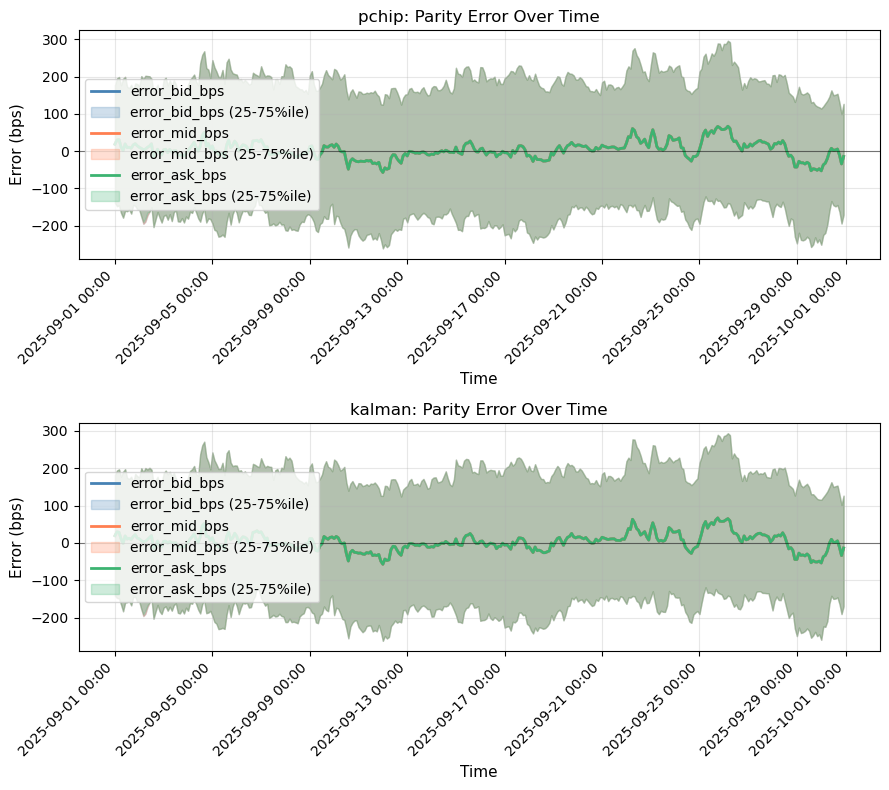

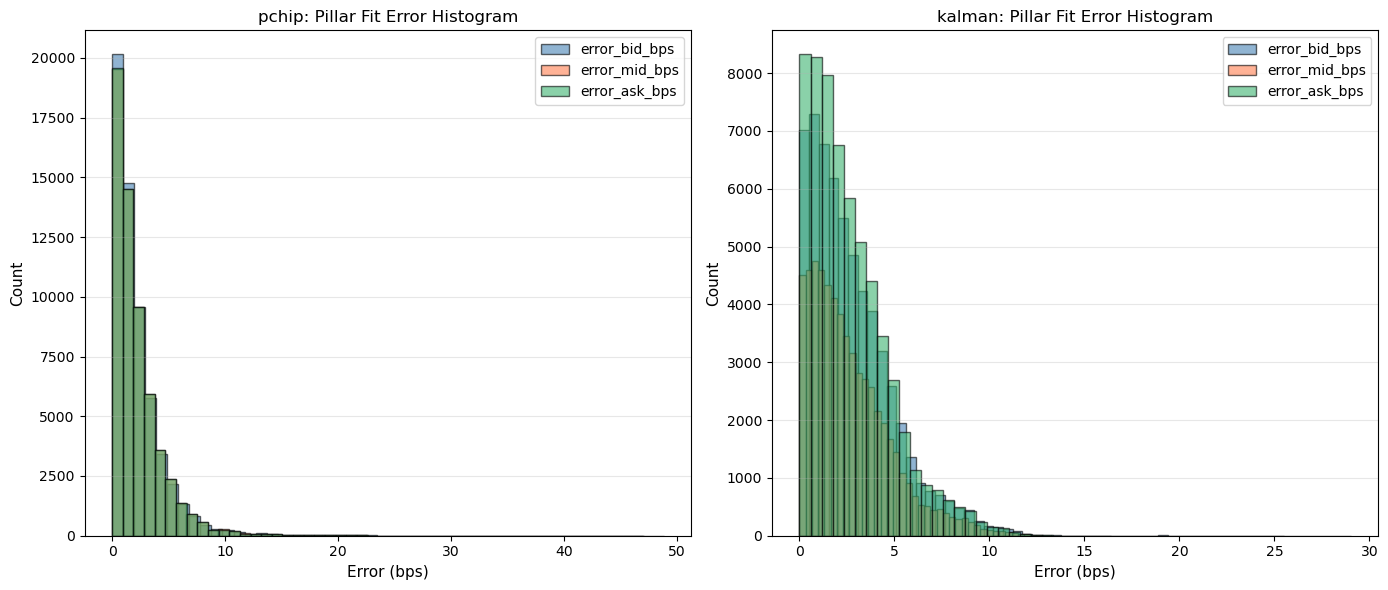

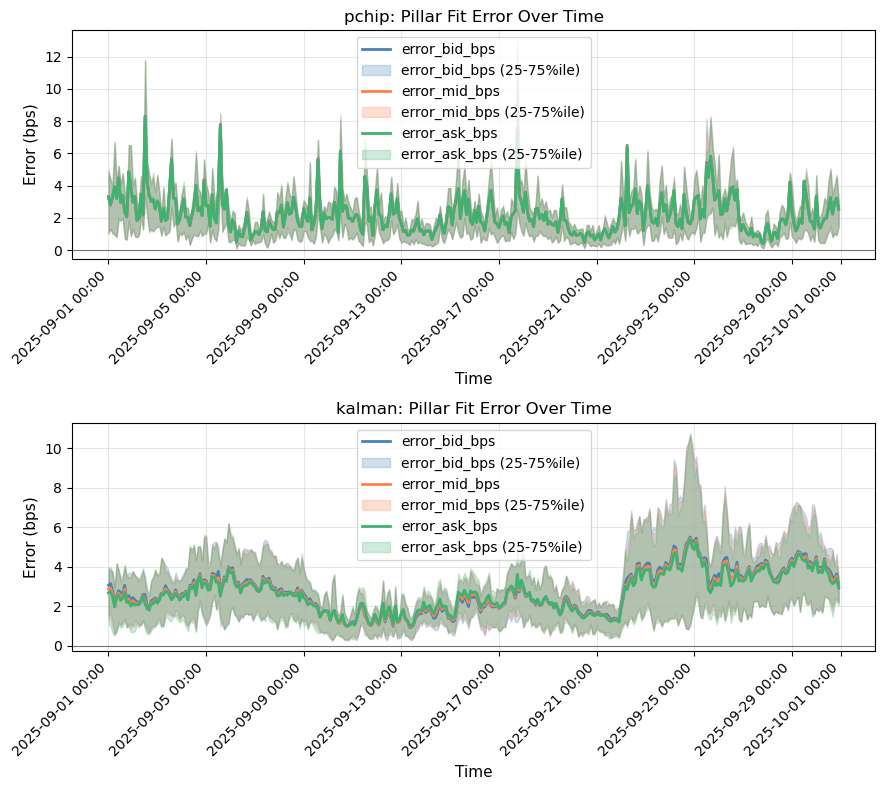

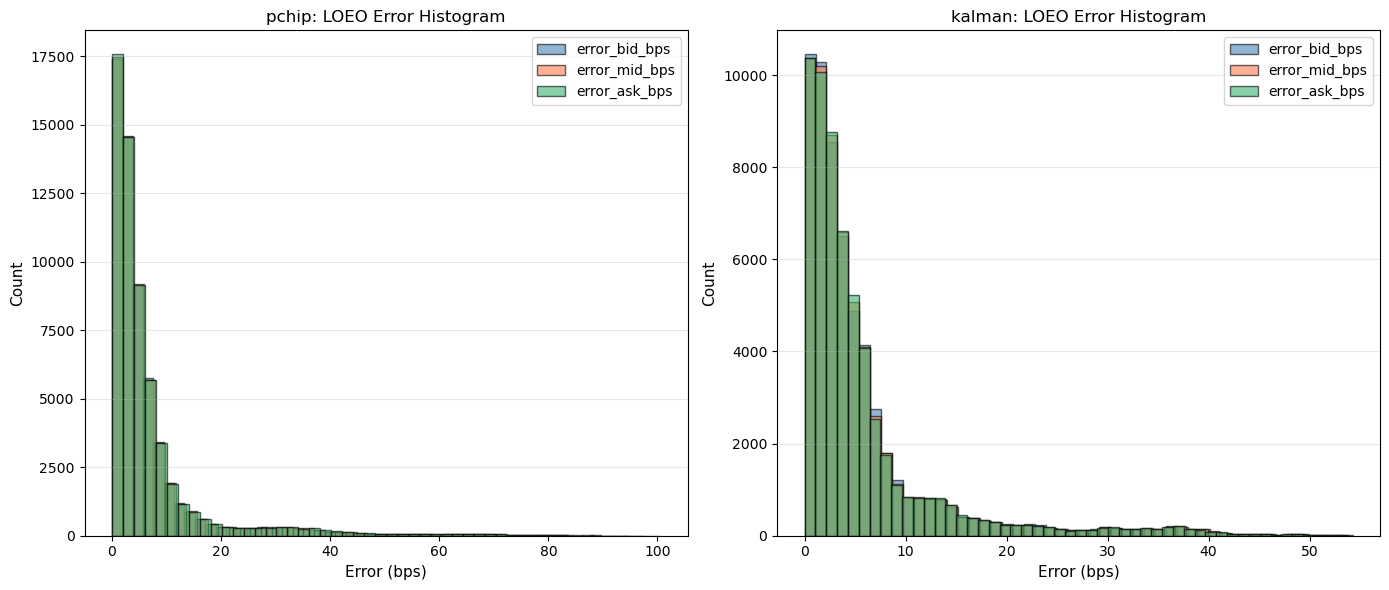

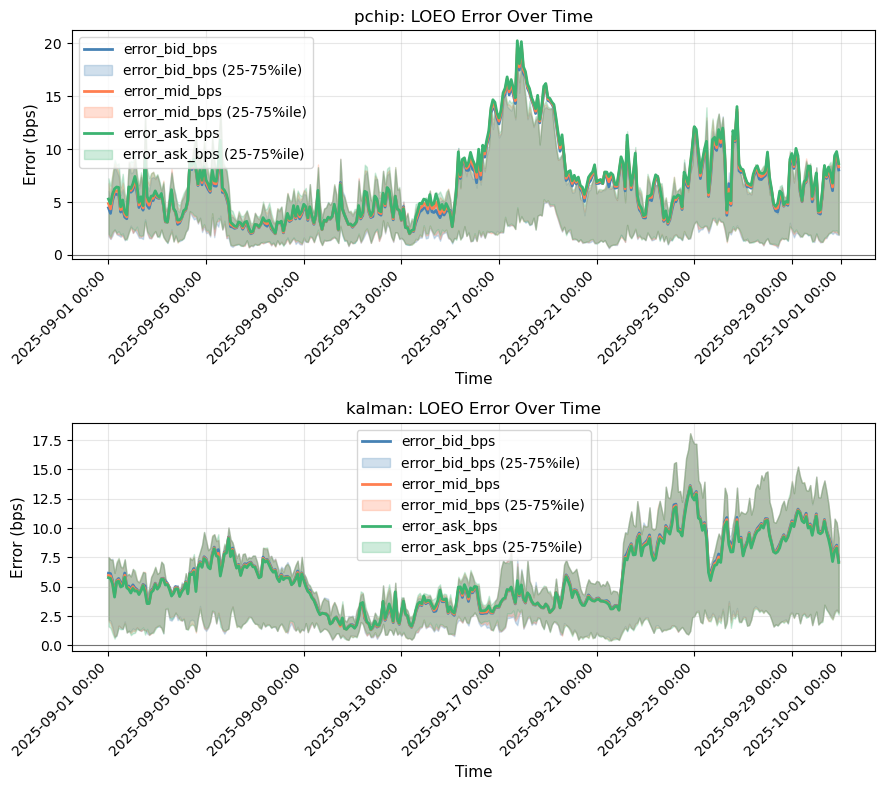

In [25]:
# ========= PLOTTING CONTROL FLAGS ========
SHOW_PARITY_HIST = False
SHOW_PARITY_TIME = True

SHOW_PILLAR_HIST = True
SHOW_PILLAR_TIME = True

SHOW_LOEO_HIST = True
SHOW_LOEO_TIME = True
# =========================================

error_cols = ['error_bid_bps', 'error_mid_bps', 'error_ask_bps']

# ---------- Put-call parity ----------

if SHOW_PARITY_HIST:
    fig_parity_hist, axs_parity_hist = plt.subplots(1, len(recipes), figsize=(7 * len(recipes), 6))
    if len(recipes) == 1:
        axs_parity_hist = [axs_parity_hist]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_parity = results_month[recipe_name]['parity']
        ax = axs_parity_hist[idx]
        plot_error_histogram(lf_parity, recipe_name, error_cols, ax=ax)
        ax.set_title(f"{recipe_name}: Parity Error Histogram")
    plt.tight_layout()

if SHOW_PARITY_TIME:
    fig_parity_time, axs_parity_time = plt.subplots(len(recipes), 1, figsize=(9, 4 * len(recipes)))
    if len(recipes) == 1:
        axs_parity_time = [axs_parity_time]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_parity = results_month[recipe_name]['parity']
        ax = axs_parity_time[idx]
        plot_error_over_time(lf_parity, recipe_name, error_cols, ax=ax, resample_freq='2h')
        ax.set_title(f"{recipe_name}: Parity Error Over Time")
    plt.tight_layout()


# ---------- Pillar fit ----------

if SHOW_PILLAR_HIST:
    fig_pillar_hist, axs_pillar_hist = plt.subplots(1, len(recipes), figsize=(7 * len(recipes), 6))
    if len(recipes) == 1:
        axs_pillar_hist = [axs_pillar_hist]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_pillar = results_month[recipe_name]['pillar_fit']
        ax = axs_pillar_hist[idx]
        plot_error_histogram(lf_pillar, recipe_name, error_cols, ax=ax)
        ax.set_title(f"{recipe_name}: Pillar Fit Error Histogram")
    plt.tight_layout()

if SHOW_PILLAR_TIME:
    fig_pillar_time, axs_pillar_time = plt.subplots(len(recipes), 1, figsize=(9, 4 * len(recipes)))
    if len(recipes) == 1:
        axs_pillar_time = [axs_pillar_time]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_pillar = results_month[recipe_name]['pillar_fit']
        ax = axs_pillar_time[idx]
        plot_error_over_time(lf_pillar, recipe_name, error_cols, ax=ax, resample_freq='2h')
        ax.set_title(f"{recipe_name}: Pillar Fit Error Over Time")
    plt.tight_layout()

# ---------- LOEO ----------

if SHOW_LOEO_HIST:
    fig_loeo_hist, axs_loeo_hist = plt.subplots(1, len(recipes), figsize=(7 * len(recipes), 6))
    if len(recipes) == 1:
        axs_loeo_hist = [axs_loeo_hist]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_loeo = results_month[recipe_name]['loeo']
        ax = axs_loeo_hist[idx]
        plot_error_histogram(lf_loeo, recipe_name, error_cols, ax=ax)
        ax.set_title(f"{recipe_name}: LOEO Error Histogram")
    plt.tight_layout()

if SHOW_LOEO_TIME:
    fig_loeo_time, axs_loeo_time = plt.subplots(len(recipes), 1, figsize=(9, 4 * len(recipes)))
    if len(recipes) == 1:
        axs_loeo_time = [axs_loeo_time]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_loeo = results_month[recipe_name]['loeo']
        ax = axs_loeo_time[idx]
        plot_error_over_time(lf_loeo, recipe_name, error_cols, ax=ax, resample_freq='2h')
        ax.set_title(f"{recipe_name}: LOEO Error Over Time")
    plt.tight_layout()

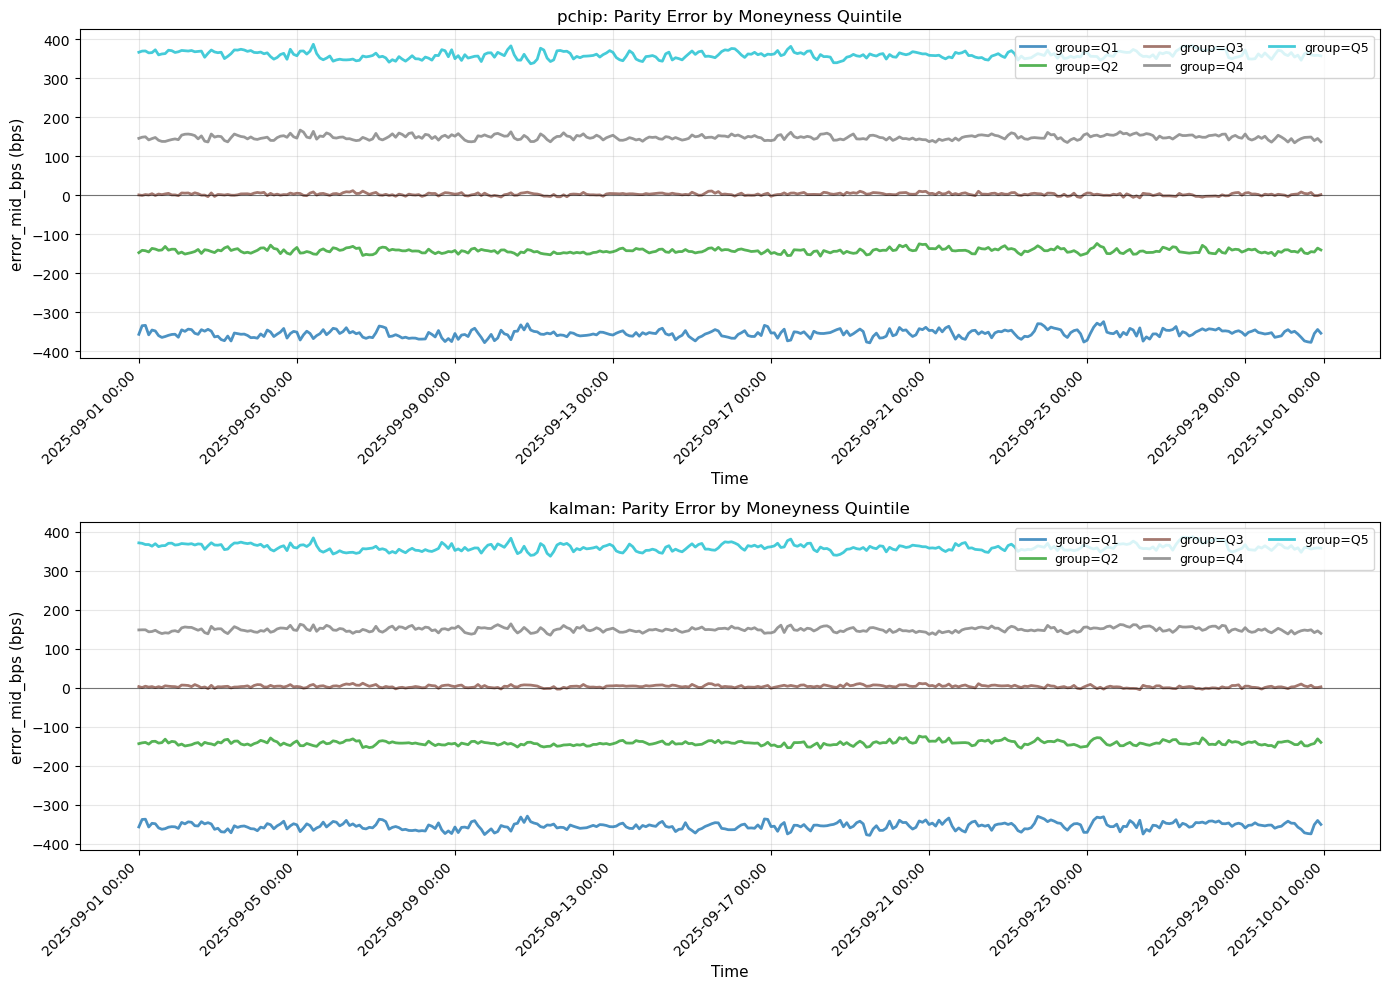

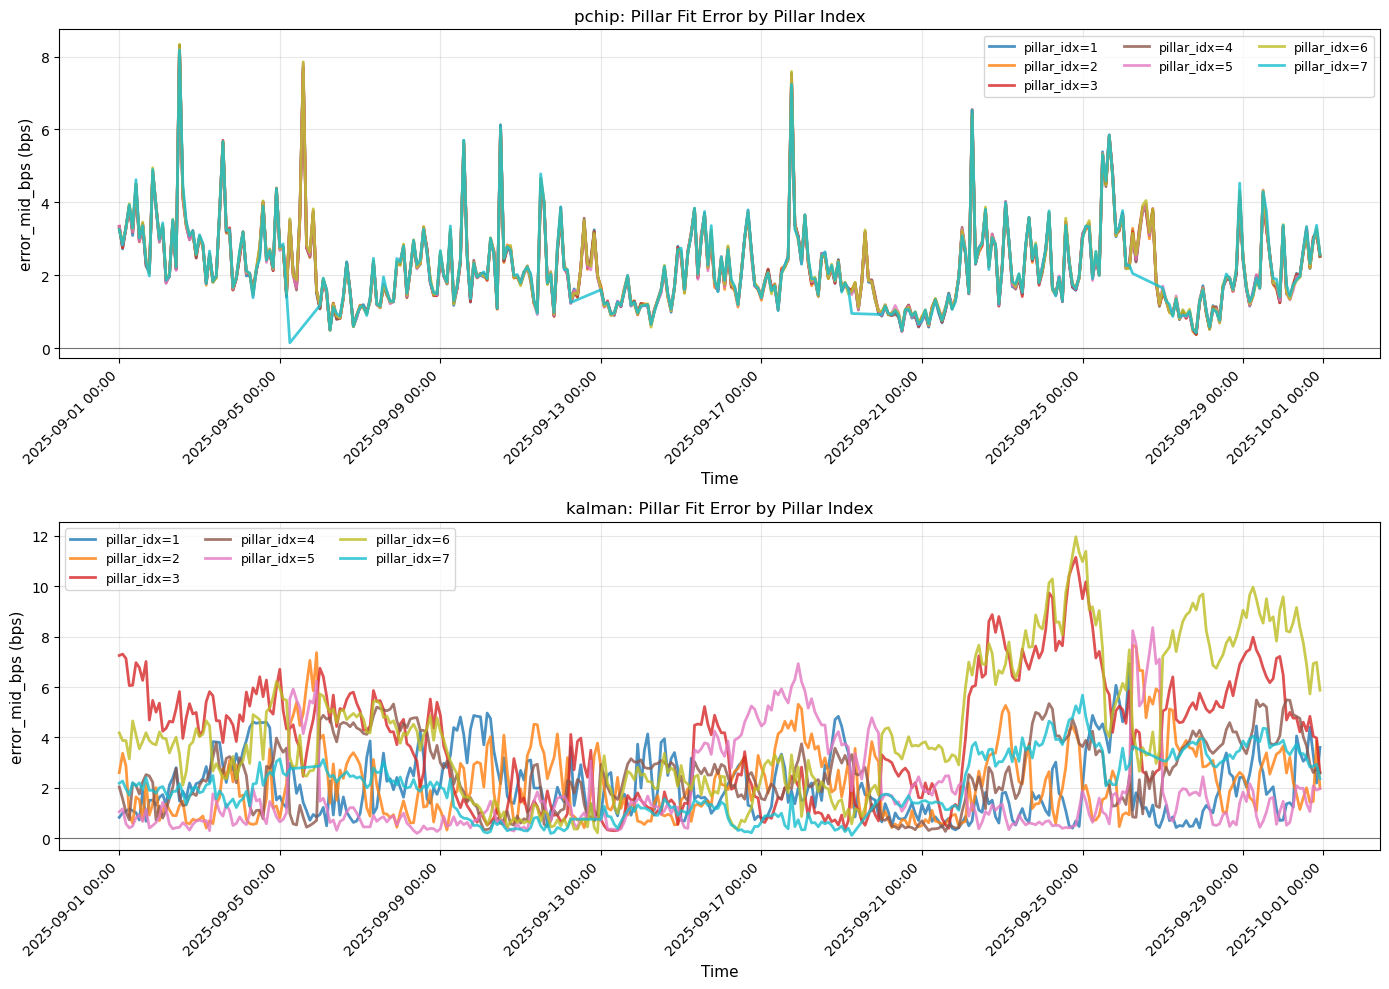

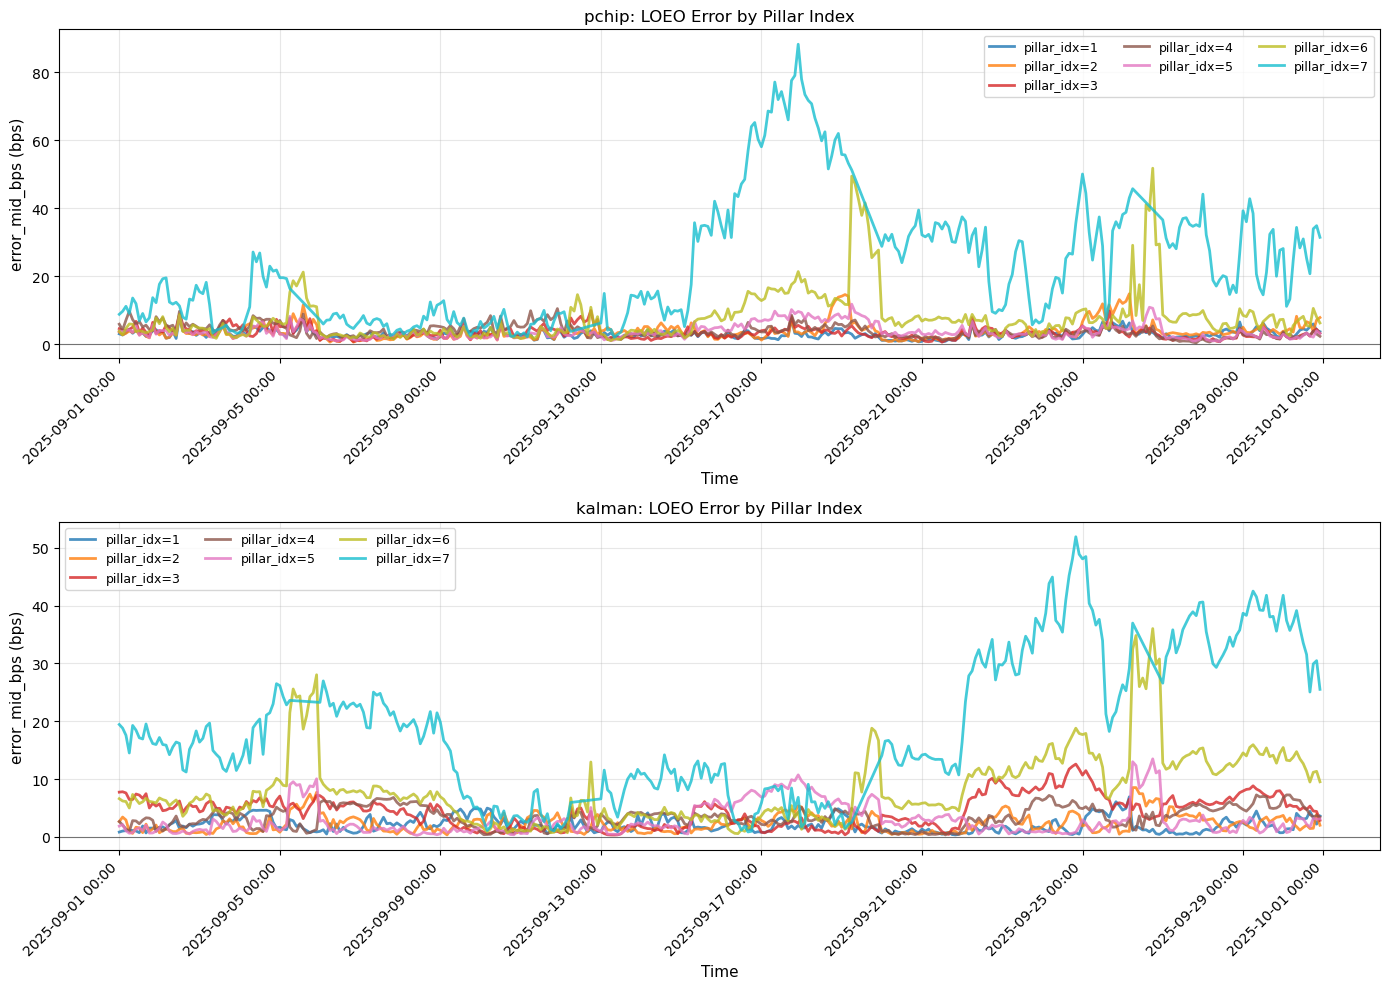

In [28]:
# ========= GROUPED ERROR PLOTS =========
SHOW_PARITY_BY_MONEYNESS = True
SHOW_PILLAR_BY_PILLAR_IDX = True
SHOW_LOEO_BY_PILLAR_IDX = True
# =========================================

# ---------- Parity errors by moneyness quintiles ----------

if SHOW_PARITY_BY_MONEYNESS:
    fig_parity_moneyness, axs_parity_moneyness = plt.subplots(len(recipes), 1, figsize=(14, 5 * len(recipes)))
    if len(recipes) == 1:
        axs_parity_moneyness = [axs_parity_moneyness]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_parity = results_month[recipe_name]['parity']
        ax = axs_parity_moneyness[idx]
        plot_error_by_group(
            lf_parity, 
            method_name=recipe_name, 
            error_col='error_mid_bps',
            group_col='moneyness',
            n_bins=5,  # Quintiles
            ax=ax, 
            resample_freq='2h'
        )
        ax.set_title(f"{recipe_name}: Parity Error by Moneyness Quintile")
    plt.tight_layout()


# ---------- Pillar fit errors by pillar_idx ----------

if SHOW_PILLAR_BY_PILLAR_IDX:
    fig_pillar_by_idx, axs_pillar_by_idx = plt.subplots(len(recipes), 1, figsize=(14, 5 * len(recipes)))
    if len(recipes) == 1:
        axs_pillar_by_idx = [axs_pillar_by_idx]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_pillar = results_month[recipe_name]['pillar_fit']
        ax = axs_pillar_by_idx[idx]
        plot_error_by_group(
            lf_pillar,
            method_name=recipe_name,
            error_col='error_mid_bps',
            group_col='pillar_idx',
            ax=ax,
            resample_freq='2h'
        )
        ax.set_title(f"{recipe_name}: Pillar Fit Error by Pillar Index")
    plt.tight_layout()


# ---------- LOEO errors by pillar_idx ----------

if SHOW_LOEO_BY_PILLAR_IDX:
    fig_loeo_by_idx, axs_loeo_by_idx = plt.subplots(len(recipes), 1, figsize=(14, 5 * len(recipes)))
    if len(recipes) == 1:
        axs_loeo_by_idx = [axs_loeo_by_idx]
    for idx, recipe_name in enumerate(recipes.keys()):
        lf_loeo = results_month[recipe_name]['loeo']
        ax = axs_loeo_by_idx[idx]
        plot_error_by_group(
            lf_loeo,
            method_name=recipe_name,
            error_col='error_mid_bps',
            group_col='pillar_idx',
            ax=ax,
            resample_freq='2h'
        )
        ax.set_title(f"{recipe_name}: LOEO Error by Pillar Index")
    plt.tight_layout()


---

## Key Takeaways

This evaluation framework provides a comprehensive assessment of forward curve quality:

1. **Put-call parity** validates consistency with options market
2. **Pillar fit** measures how well the curve fits observed forward prices
3. **LOEO** tests out-of-sample prediction performance

The modular design allows easy comparison across:
- Different recipes (PCHIP vs Kalman)
- Different time horizons (full month vs single day)
- Different sampling strategies (binning vs option timestamps)